## Operator Study

This notebook focuses on studying single operator surgery, comparing different approaches against baseline. We also test different compression strategies and the effects of combining them (operator replacement, low-rank factorization, ...)

### Operator architecture

For the current dense-model scope, write the teacher SwiGLU MLP at layer $l$ as

$$
f_l(h)=W_{\mathrm{down}}\left[\mathrm{SiLU}(W_{\mathrm{gate}}h)\odot(W_{\mathrm{up}}h)\right],
$$

$h$ is the normalized MLP input and $f_l(h)$ is the contribution returned to the residual stream. A drop-in operator $\hat f_l$ replaces only $f_l$, with the same input and output shape; the surrounding Transformer block remains unchanged.

### Operator classes: Design space relevant to this thesis

The table maps candidate operators to the question each one can answer. Parameter scales ignore biases, with $d=d_{\mathrm{model}}$ and reduced width or rank $r<d$.

| Operator class | Representative form | Approximate parameters | Experimental role | Baseline |
| --- | --- | ---: | --- | :---: |
| Zero / mean controls | $0$ or $\mu_y$ | 0 trainable | Bound complete removal and input-independent prediction. | true |
| Dense affine map | $Ax+b$ | $d^2+d$ | Test whether one learned affine transformation is sufficient. | true |
| Low-rank affine map | $U(Vx)+b$ | $2dr+d$ | Test whether linear structure is sufficient under a rank bottleneck. | false |
| Compact ungated MLP | $W_2\phi(W_1x)$ | $2dr$ | Isolate the value of nonlinearity without multiplicative gating. | false |
| Reduced-width SwiGLU | $W_d[\mathrm{SiLU}(W_gx)\odot(W_ux)]$ | $3dr$ | Preserve the teacher family at lower width; this is the current practical baseline. | true |
| Linear plus nonlinear correction | $U(Vx)+W_2\phi(W_1x)$ | $2d(r_{\mathrm{lin}}+r_{\mathrm{nl}})$ | Test whether most behavior is low-rank linear with a small nonlinear residual. | false |
| Factorized teacher projections | $W_j\approx U_jV_j$ inside SwiGLU | depends on selected matrices and ranks | Compress original weights while retaining the gate and activation structure. | false |
| Partial internal replacement | Replace only a projection, gate branch, or activation path | design-specific | Test whether targeted surgery outperforms replacing the complete MLP. | false |

Whole-block operators are studied first because they share one clean drop-in interface. Partial replacement and factorization are later experiments and require their own controls.

**Status and citation requirement.** This table is a project design-space synthesis, not a taxonomy copied from one paper. The affine, low-rank, compact-MLP, and hybrid equations are explanatory operator definitions and do not require citations as proposed experimental variants. Any claim that a particular published method uses or benefits from one of them must cite that method.

### Low-rank factorization: two distinct uses

1. **Whole-operator approximation:** $\hat f(x)=U(Vx)+b$ replaces the nonlinear MLP with one low-rank affine function.
2. **Internal weight factorization:** $W_j\approx U_jV_j$ replaces selected SwiGLU weight matrices while retaining the nonlinear gated computation.

These approaches may use the same matrix factorization machinery, but they test different hypotheses and should be reported separately.

### Experiment ideas

1. Operator class testing - fit and test full operators (dense) - test loss (local), loss (model-wide e.g. ppl)
2. Apply algebraic redundancy techniques - low-rank factorization

- we can first maybe test full operators, then maybe advanced operators and as chaining of compression techniques compare operators to factorization optimized operators to see differences and tradeoffs

- idea: plot multiple selected blocks statistics (e.g. layer=3, 10, 18) to see how it diverges/converges, analyzing block depth behaviour -> hue=layer_index


### Setup

In [1]:
from dataclasses import asdict
from datetime import datetime, timezone
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import collect_modules_io
from mlp_replacement.config import (
    DataConfig,
    ModelConfig,
    OperatorConfig,
    RecoveryConfig,
)
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.language_model import evaluate_language_model
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import (
    BottleneckMLPReplacement,
    GatedMLPReplacement,
    HybridReplacement,
    LinearReplacement,
    LowRankLinearReplacement,
    MeanReplacement,
    ZeroReplacement,
    fit_operator,
    fit_ridge_linear,
    initialize_low_rank_from_linear,
    linear_svd,
)
from mlp_replacement.recovery import cache_teacher_logits
from mlp_replacement.replacement_sensitivity import (
    evaluate_replacement_sensitivity,
)
from mlp_replacement.surgery import (
    count_parameters,
    count_state_elements,
    temporary_replacement,
)

In [4]:
SEED = 21
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
TARGET_LAYER = 11
LINEAR_RIDGE = 1e-4
KL_RECOVERY_UPDATE_BUDGET = 64

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=KL_RECOVERY_UPDATE_BUDGET,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

training_config = OperatorConfig(
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

In [7]:
model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
block = get_mlp_block(model, TARGET_LAYER)

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 5635.94it/s]


In [8]:
loaders = build_data_loaders(
    tokenizer,
    data_config,
    include_recovery=True,
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


### Operator initialization

In [9]:
OPERATOR_SPECS = [
    {'name': 'zero', 'kind': 'zero', 'baseline': True},
    {'name': 'mean', 'kind': 'mean', 'baseline': True},
    {
        'name': 'linear',
        'kind': 'ridge',
        'bias': False,
        'baseline': True,
    },
    {
        'name': 'affine',
        'kind': 'ridge',
        'bias': True,
        'baseline': True,
    },
    {
        'name': 'svd_low_rank_0.50',
        'kind': 'low_rank',
        'rank_ratio': 0.50,
        'baseline': False,
    },
    {
        'name': 'mlp_0.50',
        'kind': 'mlp',
        'width_ratio': 0.50,
        'activation': 'silu',
        'baseline': False,
    },
    {
        'name': 'swiglu_0.25',
        'kind': 'swiglu',
        'width_ratio': 0.25,
        'baseline': True,
    },
    {
        'name': 'swiglu_0.50',
        'kind': 'swiglu',
        'width_ratio': 0.50,
        'baseline': True,
    },
    {
        'name': 'swiglu_0.75',
        'kind': 'swiglu',
        'width_ratio': 0.75,
        'baseline': True,
    },
    {
        'name': 'hybrid_0.25_0.25',
        'kind': 'hybrid',
        'rank_ratio': 0.25,
        'width_ratio': 0.25,
        'activation': 'silu',
        'baseline': False,
    },
]

## Experiments

layer selection

In [10]:
#TARGET_LAYERS = [3, 11, 19]
TARGET_LAYERS = list(range(1, model.config.num_hidden_layers - 1))

### Operator classes

In [11]:
def fit_operator_spec(
    spec, training_pairs, validation_pairs, intermediate_width, fitted
):
    kind = spec['kind']
    hidden_size = training_pairs.hidden_size
    torch.manual_seed(SEED)

    if kind == 'zero':
        return ZeroReplacement().to(device), None
    if kind == 'mean':
        return MeanReplacement(
            training_pairs.targets.mean(dim=0)
        ).to(device), None
    if kind == 'ridge':
        return fit_ridge_linear(
            training_pairs,
            ridge=LINEAR_RIDGE,
            bias=spec['bias'],
            device=device,
        ).to(device), None
    if kind == 'low_rank':
        rank = max(1, round(spec['rank_ratio'] * hidden_size))
        module = initialize_low_rank_from_linear(
            LowRankLinearReplacement(hidden_size, rank),
            fitted['linear'],
        )
    elif kind == 'mlp':
        module = BottleneckMLPReplacement(
            hidden_size,
            spec['width_ratio'],
            activation=spec['activation'],
        )
    elif kind == 'swiglu':
        width = max(1, round(
            spec['width_ratio'] * intermediate_width
        ))
        module = GatedMLPReplacement(hidden_size, width)
    elif kind == 'hybrid':
        rank = max(1, round(spec['rank_ratio'] * hidden_size))
        width = max(1, round(spec['width_ratio'] * hidden_size))
        module = HybridReplacement(
            hidden_size,
            rank,
            width,
            activation=spec['activation'],
        )
    else:
        raise ValueError(f"Unknown operator kind: {kind}")

    fit = fit_operator(
        module,
        training_pairs,
        validation_pairs,
        training_config,
        device,
    )
    return fit.module, fit

In [12]:
target_blocks = {
    layer: get_mlp_block(model, layer) for layer in TARGET_LAYERS
}
target_paths = [block.path for block in target_blocks.values()]
capture_kwargs = {
    'device': device,
    'storage_device': 'cpu',
    'storage_dtype': torch.float32,
}
training_pairs_by_path = collect_modules_io(
    model,
    target_paths,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)
validation_pairs_by_path = collect_modules_io(
    model,
    target_paths,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

fitted_operators_by_layer = {}
operator_rows = []
for layer, block in target_blocks.items():
    training_pairs = training_pairs_by_path[block.path]
    validation_pairs = validation_pairs_by_path[block.path]
    intermediate_width = int(block.module.up_proj.out_features)
    original_parameters = count_parameters(block.module)
    fitted_operators = {}

    for spec in OPERATOR_SPECS:
        module, fit = fit_operator_spec(
            spec,
            training_pairs,
            validation_pairs,
            intermediate_width,
            fitted_operators,
        )
        local = evaluate_operator(
            module,
            validation_pairs,
            device,
            training_config.batch_size,
        )
        parameters = count_parameters(module)
        operator_rows.append({
            'layer': layer,
            'operator': spec['name'],
            'kind': spec['kind'],
            'baseline': spec['baseline'],
            'parameters': parameters,
            'state_elements': count_state_elements(module),
            'relative_block_parameters': (
                parameters / original_parameters
            ),
            'local_mse': local.mse,
            'local_relative_mse': local.relative_mse,
            'local_cosine': local.cosine_similarity,
            'best_epoch': fit.best_epoch if fit else 0,
        })
        fitted_operators[spec['name']] = module.to('cpu')

    fitted_operators_by_layer[layer] = fitted_operators

operator_df = pd.DataFrame(operator_rows).sort_values([
    'layer', 'operator'
]).reset_index(drop=True)
operator_df

,layer,operator,kind,baseline,parameters,state_elements,relative_block_parameters,local_mse,local_relative_mse,local_cosine,best_epoch
0,1,affine,ridge,True,4196352,4196352,0.083374,5.867828,0.127117,0.205565,0
1,1,hybrid_0.25_0.25,hybrid,False,4194304,4194304,0.083333,2.985520,0.064676,0.093736,64
2,1,linear,ridge,True,4194304,4194304,0.083333,5.979935,0.129546,0.202903,0
3,1,mean,mean,True,0,2048,0.000000,45.016407,0.975207,0.329224,0
4,1,mlp_0.50,mlp,False,4194304,4194304,0.083333,1.525660,0.033051,0.077228,64
...,...,...,...,...,...,...,...,...,...,...,...
215,22,svd_low_rank_0.50,low_rank,False,4194304,4194304,0.083333,59.440882,0.112727,0.649416,38
216,22,swiglu_0.25,swiglu,True,12582912,12582912,0.250000,43.840898,0.083142,0.716443,64
217,22,swiglu_0.50,swiglu,True,25165824,25165824,0.500000,42.049084,0.079744,0.729782,64
218,22,swiglu_0.75,swiglu,True,37748736,37748736,0.750000,41.695925,0.079074,0.734011,50


#### KL-reduction analysis

In [13]:
teacher_validation_cache = cache_teacher_logits(
    model,
    loaders.model_validation,
    data_config.num_model_validation_batches,
    device,
    recovery_config.cache_dtype,
)
sensitivity_records = evaluate_replacement_sensitivity(
    model=model,
    candidates_by_layer=fitted_operators_by_layer,
    recovery_loader=loaders.recovery,
    validation_cache=teacher_validation_cache,
    recovery_config=recovery_config,
    update_budget=KL_RECOVERY_UPDATE_BUDGET,
    device=device,
)
sensitivity_df = pd.DataFrame(
    record.to_dict() for record in sensitivity_records
).merge(
    operator_df,
    on=['layer', 'operator'],
    validate='one_to_one',
)
sensitivity_df

,layer,operator,recovery_updates,pre_recovery_kl,post_recovery_kl,kl_reduction,kind,baseline,parameters,state_elements,relative_block_parameters,local_mse,local_relative_mse,local_cosine,best_epoch
0,1,zero,64,7.915620,7.915620,0.000000,zero,True,0,0,0.000000,46.160882,1.000000,0.000000,0
1,1,mean,64,8.181346,8.181346,0.000000,mean,True,0,2048,0.000000,45.016407,0.975207,0.329224,0
2,1,linear,64,3.800706,3.805639,-0.004933,ridge,True,4194304,4194304,0.083333,5.979935,0.129546,0.202903,0
3,1,affine,64,4.075284,4.069687,0.005596,ridge,True,4196352,4196352,0.083374,5.867828,0.127117,0.205565,0
4,1,svd_low_rank_0.50,64,3.863366,3.855901,0.007465,low_rank,False,4194304,4194304,0.083333,5.979016,0.129526,0.194812,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,22,mlp_0.50,64,3.738679,3.712054,0.026625,mlp,False,4194304,4194304,0.083333,179.312159,0.340056,0.664717,64
216,22,swiglu_0.25,64,1.298094,1.256998,0.041096,swiglu,True,12582912,12582912,0.250000,43.840898,0.083142,0.716443,64
217,22,swiglu_0.50,64,0.625002,0.581491,0.043511,swiglu,True,25165824,25165824,0.500000,42.049084,0.079744,0.729782,64
218,22,swiglu_0.75,64,0.825102,0.764955,0.060147,swiglu,True,37748736,37748736,0.750000,41.695925,0.079074,0.734011,50


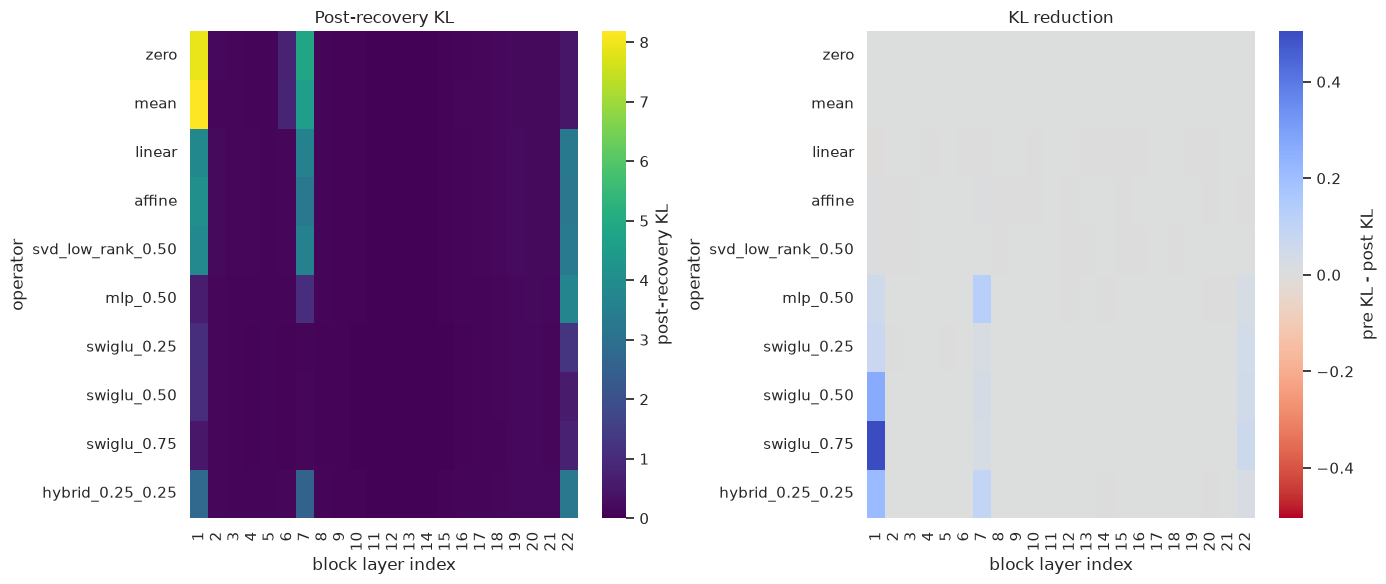

In [14]:
operator_order = [spec['name'] for spec in OPERATOR_SPECS]
post_kl_matrix = (
    sensitivity_df.pivot(
        index='operator',
        columns='layer',
        values='post_recovery_kl',
    )
    .reindex(index=operator_order, columns=TARGET_LAYERS)
)
kl_reduction_matrix = (
    sensitivity_df.pivot(
        index='operator',
        columns='layer',
        values='kl_reduction',
    )
    .reindex(index=operator_order, columns=TARGET_LAYERS)
)
reduction_limit = max(
    kl_reduction_matrix.abs().max().max(), 1e-12
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.heatmap(
    post_kl_matrix,
    cmap='viridis',
    vmin=0,
    cbar_kws={'label': 'post-recovery KL'},
    ax=axes[0],
)
sns.heatmap(
    kl_reduction_matrix,
    cmap='coolwarm_r',
    vmin=-reduction_limit,
    vmax=reduction_limit,
    center=0,
    cbar_kws={'label': 'pre KL - post KL'},
    ax=axes[1],
)
axes[0].set_title('Post-recovery KL')
axes[1].set_title('KL reduction')
for axis in axes:
    axis.set(xlabel='block layer index', ylabel='operator')
plt.tight_layout()

### Advanced Personalized Operators

### Model Integration Loss analysis

- status: draft
- comparing different operators and required re-training budgets for performance convergence
    - answers: how much compute does operator need to stabilize model loss (ppl)?

___
## Applied secondary compression techniques

1. low-rank factorization (algebraic redundancy)
2. Quantization (numeric redundancy) [optional]

___
### Artifacts

Saving performed analyses for reuse

In [15]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'operator-experiments.json'
)
artifact = {
    'schema_version': 1,
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'configuration': {
        'model': {
            **asdict(model_config),
            'resolved_revision': getattr(
                model.config, '_commit_hash', None
            ),
        },
        'data': asdict(data_config),
        'operator_training': asdict(training_config),
        'recovery': {
            **asdict(recovery_config),
            'update_budget': KL_RECOVERY_UPDATE_BUDGET,
            'trainable_scope': 'replacement_only',
            'teacher_logit_mode': 'batch_streaming',
        },
        'target_layers': list(TARGET_LAYERS),
        'linear_ridge': LINEAR_RIDGE,
        'operator_specs': OPERATOR_SPECS,
    },
    'results': {
        'operator_fitting': json_records(operator_df),
        'replacement_sensitivity': json_records(
            sensitivity_df
        ),
    },
}

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH.write_text(
    json.dumps(artifact, indent=2, allow_nan=False),
    encoding='utf-8',
)
print(f'Saved operator artifact to {OUTPUT_PATH}')

Saved operator artifact to /home/sgulas/thesis/development/data/results/notebook-block-study/operator-experiments.json
